# Final Project Draft: Online Retail Machine Learning Project

**Author**: Trace Thomason

**Date**: 4-3-26

## Problem Statement and Dataset

This project aims to predict future sales revenue and analyze customer purchasing behavior using an e-commerce dataset. Businesses often struggle to forecast sales and identify high-value customers, which impacts decision-making in marketing, inventory management, and revenue planning.

The dataset used is the Online Retail dataset, which contains over 500,000 transactions from a UK-based online store. It includes information such as product details, purchase quantities, prices, and timestamps. Machine learning techniques will be applied to forecast sales trends and understand customer behavior patterns.

## Data Loading and Exploration

In [15]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.preprocessing import StandardScaler

In [16]:
# Load Dataset

df = pd.read_csv('data/raw/online_retail.csv', encoding='ISO-8859-1')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


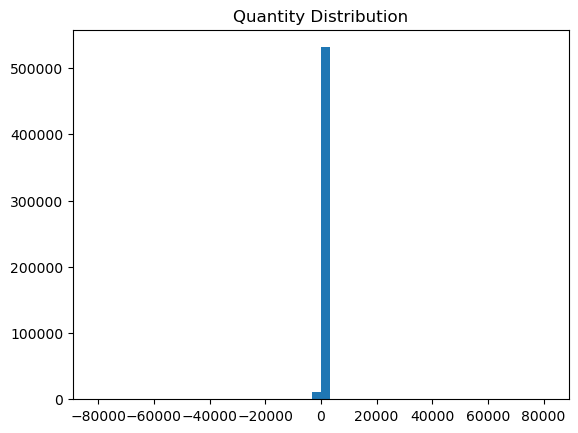

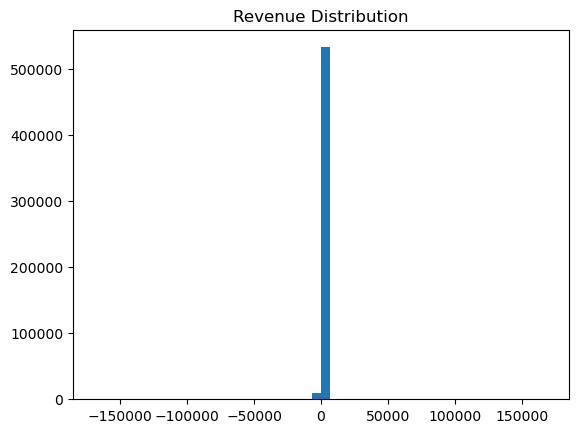

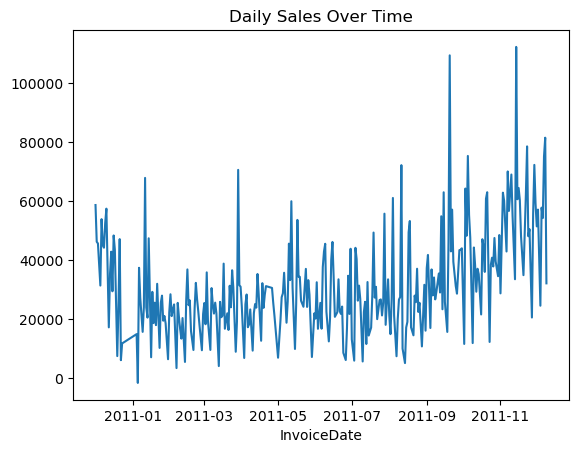

In [17]:
# Missing values
df.isnull().sum()

# Distribution of Quantity
plt.hist(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.show()

# Revenue distribution
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
plt.hist(df['TotalPrice'], bins=50)
plt.title("Revenue Distribution")
plt.show()

# Sales over time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

daily_sales.plot()
plt.title("Daily Sales Over Time")
plt.show()

## Key Data Characteristics

The dataset contains over 500,000 transactions with some missing CustomerID values and invalid entries such as negative quantities (returns). Sales data is highly skewed, with a few large transactions dominating revenue. Time-based trends suggest variability in daily sales, supporting the use of time series forecasting.

## Feature Engineering

In [18]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Recalculate total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Create Recency, Frequency, Monetary features
latest_date = df['InvoiceDate'].max()

recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (latest_date - recency).dt.days

frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

customer_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

customer_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


Three engineered features were created using the RFM framework:

- Recency: Measures how recently a customer made a purchase. Customers who purchased recently are more likely to return.
- Frequency: Counts how often a customer makes purchases, indicating loyalty.
- Monetary: Represents total spending by each customer, identifying high-value customers.

These features help capture customer behavior patterns that are not directly available in the raw dataset.

## Data Preprocessing

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = customer_df[['Recency', 'Frequency']]
y = customer_df['Monetary']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for consistency across models)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Preprocessing

The dataset was prepared for modeling using the following steps:

**Train/Test Split**
- The data was split into training and testing sets using an 80/20 ratio  
- A random split was used since this is a regression problem (no stratification required)  

**Handling Missing Values**
- Rows with missing CustomerID values were removed because customer-level analysis requires valid identifiers  
- Invalid transactions such as negative quantities (returns) and zero or negative prices were filtered out  

**Feature Scaling**
- StandardScaler was applied to the input features (Recency and Frequency)  
- Scaling ensures that features are on the same scale, which is especially important for models sensitive to feature magnitude  

These preprocessing steps ensure that the dataset is clean, consistent, and suitable for machine learning models.

## Model 1: Random Forest Regression

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 10607.143123135373
Random Forest MAE: 1960.9058802129198


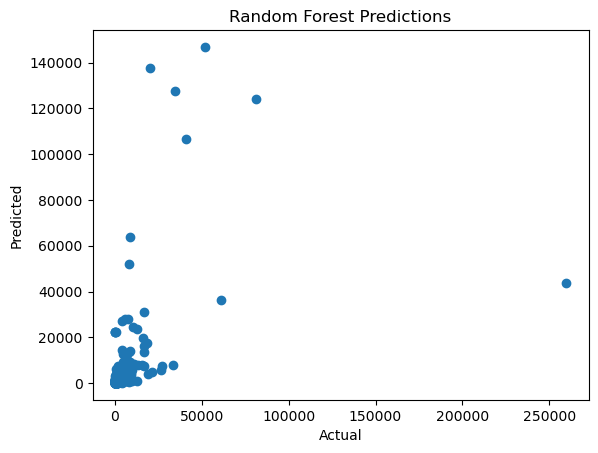

In [21]:
# Visualization

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

## Model 2: Time Series Forecasting

In [22]:
# Aggregate daily sales
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
daily_sales = pd.Series(daily_sales)

# Create lag feature
ts_df = pd.DataFrame({'Sales': daily_sales})
ts_df['Lag1'] = ts_df['Sales'].shift(1)
ts_df = ts_df.dropna()

# Train/test split (time-based)
split = int(len(ts_df) * 0.8)
train = ts_df[:split]
test = ts_df[split:]

X_train_ts = train[['Lag1']]
y_train_ts = train['Sales']

X_test_ts = test[['Lag1']]
y_test_ts = test['Sales']

# Train model
rf_ts = RandomForestRegressor()
rf_ts.fit(X_train_ts, y_train_ts)

# Predict
y_pred_ts = rf_ts.predict(X_test_ts)

# Metrics
rmse_ts = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
mae_ts = mean_absolute_error(y_test_ts, y_pred_ts)

print("Time Series RMSE:", rmse_ts)
print("Time Series MAE:", mae_ts)

Time Series RMSE: 30460.216632111824
Time Series MAE: 21049.004617704926


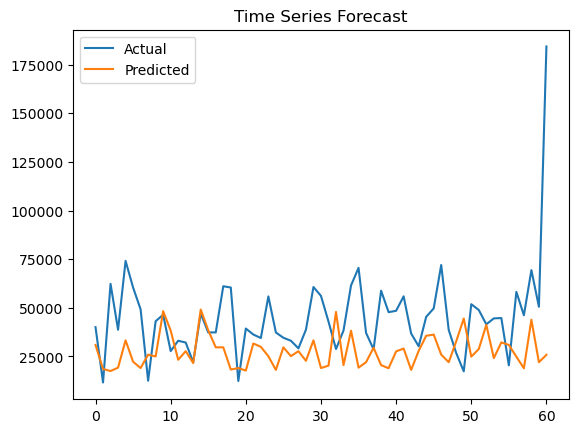

In [23]:
# Visualization

plt.plot(y_test_ts.values, label='Actual')
plt.plot(y_pred_ts, label='Predicted')
plt.legend()
plt.title("Time Series Forecast")
plt.show()

## Model Comparison

In [24]:
comparison = pd.DataFrame({
    'Model': ['Random Forest (Customer)', 'Time Series Model'],
    'RMSE': [rmse_rf, rmse_ts],
    'MAE': [mae_rf, mae_ts]
})

comparison

,Model,RMSE,MAE
0,Random Forest (Customer),10607.143123,1960.905880
1,Time Series Model,30460.216632,21049.004618


The time series model performed better at predicting overall sales trends, while the random forest model provided useful insights into customer-level spending. The main trade-off is that the time series model is better for forecasting, whereas the random forest model is more interpretable for understanding customer behavior. For the final project, the time series model will be the primary focus for improvement.

## Next Steps and Reflection

Future improvements will include creating additional engineered features such as day-of-week effects, seasonal patterns, and customer segmentation labels. I also plan to improve model performance through hyperparameter tuning and testing more advanced models such as gradient boosting or ARIMA for time series forecasting.

One area where I would like feedback is whether my time series modeling approach is appropriate or if I should use a more specialized method. Additionally, I would like guidance on improving feature engineering to better capture patterns in the data.